In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load the Digits dataset (1797 images, 8x8 pixels = 64 dimensions)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

def plot_2d_reduction(X_pca, X_tsne, y):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: PCA Plot
    scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=30)
    ax1.set_title("PCA: Linear Projection (Messy & Overlapping)")
    ax1.set_xlabel("Principal Component 1")
    ax1.set_ylabel("Principal Component 2")
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Right: t-SNE Plot
    scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7, s=30)
    ax2.set_title("t-SNE: Non-Linear Embedding (Distinct Clusters)")
    ax2.set_xlabel("t-SNE Dimension 1")
    ax2.set_ylabel("t-SNE Dimension 2")
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # Add a colorbar legend for the 10 digits
    cbar = fig.colorbar(scatter2, ax=[ax1, ax2], ticks=range(10), pad=0.02)
    cbar.set_label('Digit Class (0-9)')
    plt.show()

# Part 4: Dimensionality Reduction (Untangling the Chaos)
We have a dataset of handwritten digits. Every image is 8x8 pixels, meaning each image is a single data point floating in **64-Dimensional Space**. We humans can only see in 3D. We need to reduce this 64D data down to 2D to visualize it. Let's pit our two algorithms against each other.

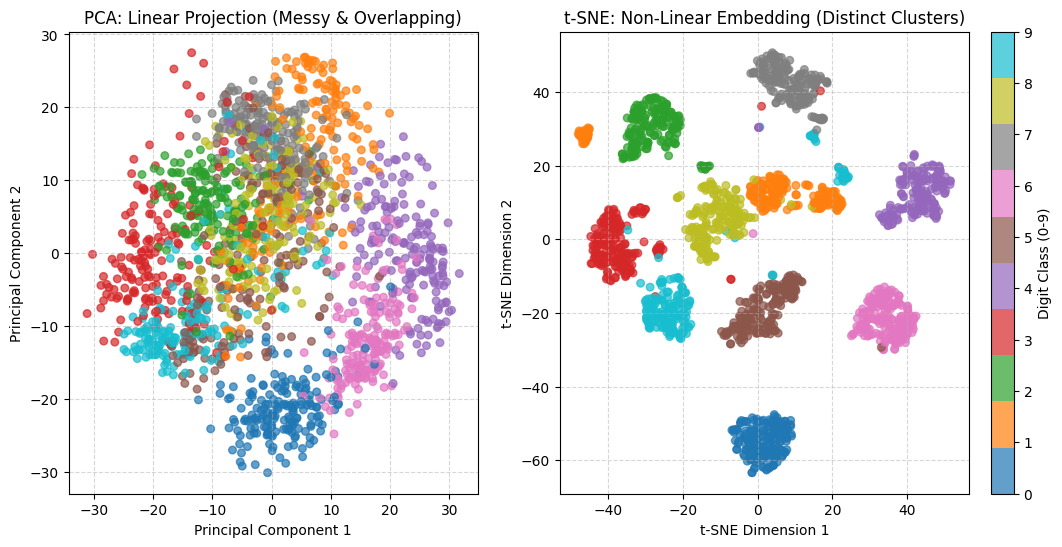

In [8]:
# 1. Initialize and run PCA (Reducing 64D -> 2D)
pca_2d = PCA(n_components = 2)
X_pca_2d = pca_2d.fit_transform(X_digits)

# 2. Initialize and run t-SNE (Reducing 64D -> 2D)
tsne_2d = TSNE(n_components=2, perplexity = 30, random_state=42)
X_tsne_2d = tsne_2d.fit_transform(X_digits)

# 3. Plot the showdown
plot_2d_reduction(X_pca_2d, X_tsne_2d, y_digits)

## If t-SNE is so much prettier, why do we use PCA?
t-SNE is a pure visualization tool. It distorts true distances to make pretty clusters, and it cannot easily transform *new* data. 

PCA is a mathematical powerhouse. It preserves global variance. If we look at the **Cumulative Explained Variance** (the Scree Plot), PCA will tell us exactly how much of the original 64-dimensional information is retained as we increase the number of components.

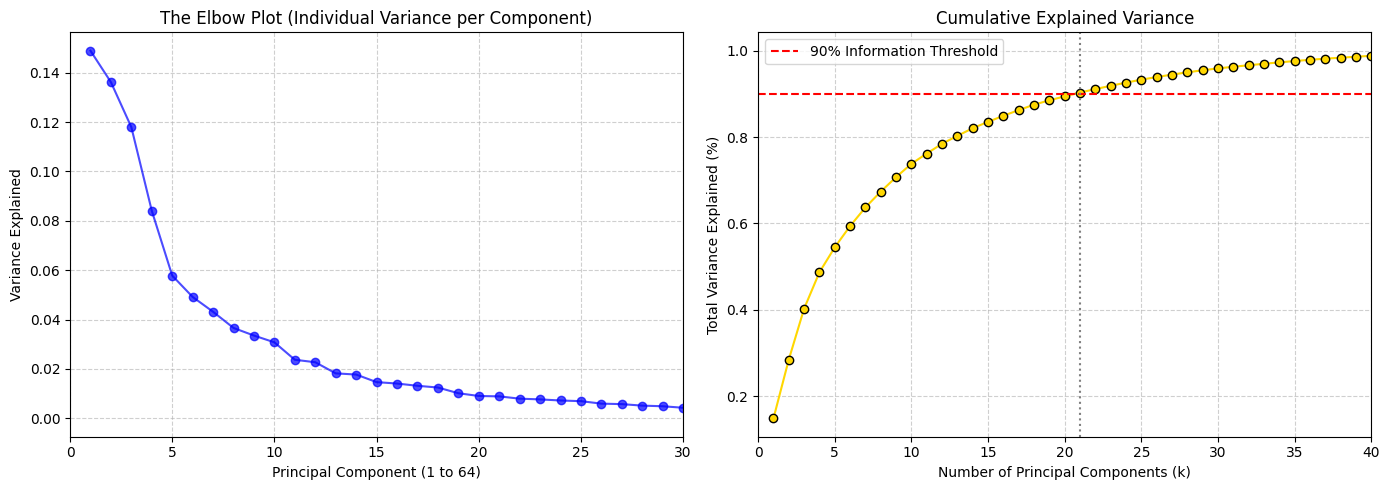

In [10]:
# Run PCA keeping ALL 64 components to calculate their variance
pca_full = PCA(n_components=None)
pca_full.fit(X_digits)

# Get the individual variance of each component (This creates the "Elbow")
individual_variance = pca_full.explained_variance_ratio_
# Get the cumulative variance (To see when we hit 90%)
cumulative_variance = np.cumsum(individual_variance)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT PLOT: The Classic Elbow Plot (Individual Variance)
ax1.plot(range(1, 65), individual_variance, marker='o', color='blue', alpha=0.7)
ax1.set_title("The Elbow Plot (Individual Variance per Component)")
ax1.set_xlabel("Principal Component (1 to 64)")
ax1.set_ylabel("Variance Explained")
ax1.set_xlim(0, 30) # Zoom in on the first 30 components to see the elbow clearly
ax1.grid(True, linestyle='--', alpha=0.6)

# RIGHT PLOT: Cumulative Variance (The Information Threshold)
ax2.plot(range(1, 65), cumulative_variance, marker='o', color='gold', markeredgecolor='black')
ax2.axhline(y=0.90, color='red', linestyle='--', label='90% Information Threshold')
ax2.axvline(x=21, color='gray', linestyle=':') # It takes ~21 components to hit 90%
ax2.set_title("Cumulative Explained Variance")
ax2.set_xlabel("Number of Principal Components (k)")
ax2.set_ylabel("Total Variance Explained (%)")
ax2.set_xlim(0, 40)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()